# AP 155 Lab Exercise
---
## Exercise 5: Matrices

_Instructions_: 
- **Report figure:** Plot of voltage for each node. 
- **Report discussion:**
  - What were the basis linear equations used to set up the matrix in each question of Problem 2?
  - Once you set up the matrices, what function did you use to solve the matrix equation (Could have different answers)? Check the docstring/documentation/other references and summarize the mechanism behind the function 
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Marana, Kyle
- _Student No._: 2024-14996
- _Section_: WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

<!-- ### Report figure

<img src="figures/cat.jpg" alt="Alt text" width=45%> <img src="figures/cat.jpg" alt="Alt text" width=45%>

![A](fig1.png)

### Report discussion

EDIT ME. See instruction above for what to include. Insert your discussions here. Discuss your key results with at most 150 words per question.

### Other comments
- EDIT ME
- A self reflection can be placed here.
- This portion is not graded.
- You may insert further questions here.


---
## Section 1: Report

![A](fig1.png)
**Figure 1. Voltage Distribution for N = 10,000**

This graph shows the distribution of voltage as the number of node increases. The graph shows a linear line dropping linearly from 5V to 0V as the number of node increases. This drop is due to 

---
## Section 2: Code

### Problem 1: (Newman 6.7) Resistor Ladder

**READ THE INSTRUCTIONS COMPLETELY**

Consider a long chain of resistors wired up like this:

<img src="reschain.png" alt="Alt text" width=95%>

All the resistors have the same resistance $R$.  The power rail at the top is at voltage $V_+=5$V.  The problem is to find the voltages $V_1, \ldots, V_N$ at the internal nodes in the circuit.

1. **Using Ohm's law and the Kirchhoff current law**, which says that the total net current flow out of (or into) any junction in a circuit must be zero, show that the voltages $V_1\ldots V_N$ satisfy the equations

$$3V_1 - V_2 - V_3 = V_+ $$
$$-V_1 + 4V_2 - V_3 - V_4 = V_+ $$
$$\cdots$$
$$-V_{i-2} - V_{i-1} + 4V_i - V_{i+1} - V_{i+2} = 0 $$
$$\cdots$$
$$-V_{N-3} - V_{N-2} + 4V_{N-1} - V_N = V_- = 0 $$
$$-V_{N-2} - V_{N-1} + 3V_N = V_- = 0 $$

Note: The assignment of $V_-$ is to make the equations symmetric

2. Express these equations in vector form $A\vec{v} = \vec{w}$ and find the values of the matrix $A$ and the vector $\vec{w}$.

3. Write a program to solve for the values of the $V_i$ when there are $N=6$ internal junctions with unknown voltages. (Hint: All the values of $V_i$ should lie between zero and $5$V.  If they don't, something is wrong.)

4. Now repeat your calculation for the case where there are $N=10\,000$ internal junctions.  This part is not possible using standard tools like the `np.linalg.solve` function.  You need to make use of the fact that the matrix $\vec{A}$ is banded, and uses `banded.py` by Mark Newman which can be obtained from the link: https://public.websites.umich.edu/~mejn/cp/programs.html

5. Plot your voltages in a histogram, make different histograms for varying number of nodes

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import banded as bd

In [5]:
N=6

#creating Matrix A
A = np.zeros((N,N))

for i in range(N):

    #main diagonal
    if i == 0 or i == N-1:
        A[i,i] = 3
    else:
        A[i,i] = 4

    #first off diagonal
    if i-1 >= 0:
        A[i, i-1] = -1

    if i+1 < N:
        A[i, i+1] = -1

    #second off diagonal
    if i-2 >= 0:
        A[i, i-2] = -1

    if i+2 < N:
        A[i, i+2] = -1

#creating matrix w

w = np.zeros(N)
w[0] = 5
w[1] = 5

#computing for Av = w

V = np.linalg.solve(A,w)

print("A =")
print(A)

print("\nw =")
print(w)

print("\nVoltages:")
for i in range(N):
    print(f"V{i+1} = {V[i]:.6f} V")

A =
[[ 3. -1. -1.  0.  0.  0.]
 [-1.  4. -1. -1.  0.  0.]
 [-1. -1.  4. -1. -1.  0.]
 [ 0. -1. -1.  4. -1. -1.]
 [ 0.  0. -1. -1.  4. -1.]
 [ 0.  0.  0. -1. -1.  3.]]

w =
[5. 5. 0. 0. 0. 0.]

Voltages:
V1 = 3.725490 V
V2 = 3.431373 V
V3 = 2.745098 V
V4 = 2.254902 V
V5 = 1.568627 V
V6 = 1.274510 V


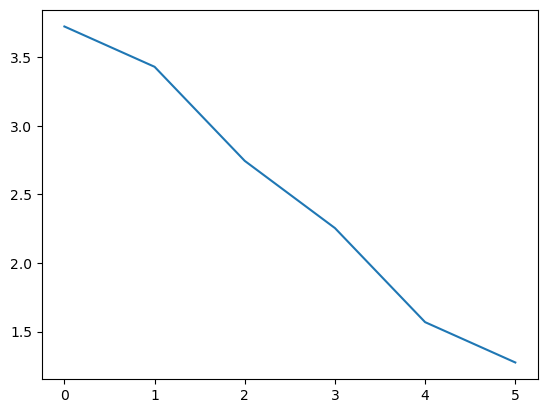

In [6]:
plt.plot(V)

In [10]:
N=10000

#constructs the banded matrix
# 5 = 2 upper/lower diagonal + main diagonal
bd_A = np.zeros((5,N))

#main diagonal
bd_A[2, :] = 4
bd_A[2, 0] = 3
bd_A[2, N-1] = 3

#first upper diagonal
bd_A[1, 1:] = -1

#second upper diagonal
bd_A[0, 2:] = -1

#first lower diagonal
bd_A[3, :-1] = -1

#second lower diagonal
bd_A[4, :-2] = -1

#righthand side vector
bd_w = np.zeros(N)

bd_w[0] = 5
bd_w[1] = 5

#computing for AV = w
bd_V = bd.banded(bd_A, bd_w, 2, 2)

print("V1 =", bd_V[0])
print("V2 =", bd_V[1])
print("V3 =", bd_V[2])

print("VN-2 =", bd_V[N-3])
print("VN-1 =", bd_V[N-2])
print("VN =", bd_V[N-1])

print("Minimum Voltage =", bd_V.min())
print("Maximum Voltage =", bd_V.max())

V1 = 4.998882277727716
V2 = 4.998618419291493
V3 = 4.9980284138916575
VN-2 = 0.001971586108334918
VN-1 = 0.0013815807085025764
VN = 0.0011177222722791647
Minimum Voltage = 0.0011177222722791647
Maximum Voltage = 4.998882277727716


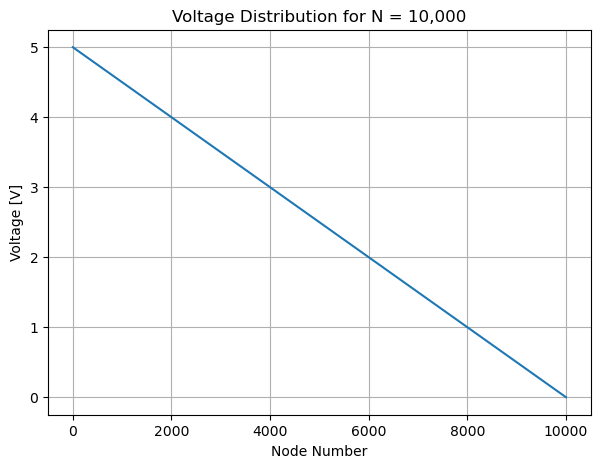

In [17]:
#graphing N=10000

nodes = np.arange(1, N+1)

plt.figure(figsize=(7,5))
plt.plot(nodes, bd_V)

plt.xlabel("Node Number")
plt.ylabel("Voltage [V]")
plt.title("Voltage Distribution for N = 10,000")
plt.grid()
plt.savefig('fig1.png', format='png', dpi=300)

plt.show()

#### Problem 1 code summary

The code above plots the voltage across different nodes in a resistor chain. The code was typed this way so that i can plot 10000 nodes without crashing by utilizing banded.py.

---

## Section 3 (Notes)

### Some codes for solving matrix problems

* solving matrix equations ($\bf{A}\vec{x} = \vec{b}$) -> `np.linalg.solve`
* LU-decomposition ($\bf{A} = \bf{L}\bf{U}$) -> `scipy.linalg.lu`
* matrix inversion ($\bf{A}^{-1}$) -> `np.linalg.inv`
* QR-decomposition ($\bf{A} = \bf{Q}\bf{R}$) -> `scipy.linalg.qr`
* eigenvalue problem ($\bf{A}\vec{x} = \lambda \vec{x}$) -> `np.linalg.eig`

Solving matrix problems by themselves isn't difficult. There is an abundance of linear algebra libraries that are ready to use: from the battle-tested ones (the classic [BLAS](https://www.netlib.org/blas/) and [LAPACK](https://www.netlib.org/lapack/)), HPC tools for large problems ([ScaLAPACK](https://netlib.org/scalapack/)), to hardware-accelerated ones often with GPUs ([cuBLAS](https://docs.nvidia.com/cuda/cublas/index.html) and [cuSolver](https://docs.nvidia.com/cuda/cusolver/index.html) for NVIDIA). 

The hardest part is actually composing the matrix. How do you transform a physical problem into a linear algebra problem?

* Circuit: https://personal.math.vt.edu/embree/cmda3606/chapter2.pdf
* Embree [main notes](https://personal.math.vt.edu/embree/cmda3606notes.pdf) + [lab manual](https://personal.math.vt.edu/embree/labman.pdf)

#### Sample Usage

### Importing functions from a python file

In [6]:
import samplePackage as sP

In [7]:
sP.createZerosArray(4,5)

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])